## Projet Final SDD-1002
#Yannick Poirier, POIY04109403



---



**Consigne :** Vous devez téléverser un seul fichier .ipynb qui contient votre code sur le portail
du cours afin que je puisse l’exécuter. Ce fichier .ipynb doit lire le contenu du
fichier heart_disease_uci.csv qui est hébergé sur votre Google Drive

In [ ]:
import requests
import pandas as pd
from sklearn.preprocessing import StandardScaler
from io import StringIO

#https://drive.google.com/file/d/1x_ohiTSgrS2RKrMCaSiSaqWRnGRKPgC5/view?usp=sharing
file_id = '1x_ohiTSgrS2RKrMCaSiSaqWRnGRKPgC5'
direct_link = f'https://drive.google.com/uc?id={file_id}'

response = requests.get(direct_link)
response.raise_for_status()  # Une erreur est soulevé si jamais il y a un problème dans chargement fichier donnees.csv
data = response.content.decode('utf-8') # Décode les bits pour permettre affichage

df = pd.read_csv(StringIO(data)) # Pandas va lire le fichier décodé
print(df.head().to_string(index=False)) # Affichage des 5 premières entrées dans la base de données sans tabulation pour être sur que tout est ok

 id  age    sex   dataset              cp  trestbps  chol   fbs        restecg  thalch exang  oldpeak       slope  ca              thal  num
  1   63   Male Cleveland  typical angina     145.0 233.0  True lv hypertrophy   150.0 False      2.3 downsloping 0.0      fixed defect    0
  2   67   Male Cleveland    asymptomatic     160.0 286.0 False lv hypertrophy   108.0  True      1.5        flat 3.0            normal    2
  3   67   Male Cleveland    asymptomatic     120.0 229.0 False lv hypertrophy   129.0  True      2.6        flat 2.0 reversable defect    1
  4   37   Male Cleveland     non-anginal     130.0 250.0 False         normal   187.0 False      3.5 downsloping 0.0            normal    0
  5   41 Female Cleveland atypical angina     130.0 204.0 False lv hypertrophy   172.0 False      1.4   upsloping 0.0            normal    0




---



#Prétraitement des Données

**a.** Gérer les valeurs manquantes : Vous devez choisir une méthode de remplissage
des données manquantes et expliquer pourquoi vous l'avez choisie.

**b.** Effectuer les conversions de types de données nécessaires en utilisant
LabelEncoder.

**d.** Normaliser/standardiser les caractéristiques.


**Réponse :** Dans un premier temps, j'ai vérifier dans quel variable il y avait des valeurs manquantes, car cela influence grandement le choix de méthode. J'ai remarqué que les valeurs affectés sont des variables continues et catégorielles. Avec cela en tête, j'ai donc opté pour deux méthode différente selon le type de données. J'ai remplis les valeurs manquantes de type catégorielle avec le mode de la colonne et j'ai remplis les valeurs manquantes de type continue avec la moyenne de la colonne. Le LabelEncoder est ensuite utilisé pour convertir les données catégorielles en numérique. Finalement, Les valeurs standardisées sont réintroduite dans le df. Grâce à StandardScaler, les caractéristiques auront une moyenne de zéro et un écart type de un.  

In [ ]:
df.isna().sum() # Voir s'il y a des valeurs manquantes parmis les variables

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [ ]:
from sklearn.preprocessing import LabelEncoder # Pour encoder variables catégorielles en numérique

# Ici on identifie les variables continues (float) avec des valeurs manquantes
variables_continues_manquantes = df.select_dtypes(include=float).columns[df.select_dtypes(include=float).isna().any()]

# Impute les valeurs continues manquantes par la moyenne
for variable in variables_continues_manquantes: # Boucle qui parcourt les valeurs manquantes continues
    moyenne = df[variable].mean() # Calcule la moyenne des valeurs NON manquantes
    df[variable].fillna(moyenne, inplace=True) # Remplis les valeurs manquantes avec la moyenne des valeurs non manquantes calculés

# Ici on identifie les variables catégorielles (object) avec des valeurs manquantes
variables_catégorielles_manquantes = df.select_dtypes(include=object).columns[df.select_dtypes(include=object).isna().any()]

# Imputer les valeurs manquantes par le mode
for variable in variables_catégorielles_manquantes: # Boucle qui parcourt les valeurs manquantes catégorielles
    mode_valeur = df[variable].mode().iloc[0] # Calcule le mode des valeurs NON manquantes (valeur la plus fréquente)
    df[variable].fillna(mode_valeur, inplace=True) # Remplis les valeurs manquantes avec le mode des valeurs non manquantes calculés

df_encoded = df.copy() # Création d'une copie du DataFrame (utilisé pour encodage et standardisation)

# Conversion des variables catégorielles en variables numériques à l'aide de LabelEncoder
label_encoder = LabelEncoder()
for column in df_encoded.select_dtypes(include='object').columns: # Boucle à travers chaque colonne de la copie du df contenant variables catégorielles
    df_encoded[column] = label_encoder.fit_transform(df_encoded[column]) # Analyse valeur unique, crée un mapping et applique le mapping
print("Encodage des étiquettes (LabelEncoder) réussie.") # Confirmation de l'encodage

# Standardise les variables continues qui ont été ajoutées pour remplacer les données manquantes
scaler = StandardScaler()
df[variables_continues_manquantes] = scaler.fit_transform(df[variables_continues_manquantes]) # Analyse variables continues, calcule paramètre, applique standardisation
print("Standardisation (StandardScaler) réussie.") # Confirmation de la standardisation

Encodage des étiquettes (LabelEncoder) réussie.
Standardisation (StandardScaler) réussie.


In [ ]:
df.isna().sum() # Vérifie que les données manquantes sont toutes remplis

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64



---



**c.** Dans une cellule de texte, comparez les méthodes OneHotEncoding, LabelEncoder et get_dummies


**Réponse :** Ces 3 méthodes sont utilisés pour convertir des variables catégorielles en variables numériques afin que les algorithmes d'apprentissage automatique puissent bien les comprendres.

OneHotEncoding : Ici, chaque valeur unique d'une variable catégorielle est représenté par une nouvelle colonne.En fait, chacune des nouvelles colonnes va indiquer la présence(1) (ou absence(0)) de la valeur correspondante dans la variable catégorielle. Une bonne utilité est lorsque les valeurs catégorielles n'ont pas d'ordre spécifique (exemple : pomme, banane, orange). Il faut quand même faire attention, car cette méthode peut créer un grand nombre de nouvelles colonnes avec des variables possédant de nombreuses catégories.

LabelEncoder : Ici, un nombre entier unique à chaque valeur de la variable catégorielle est attribué. La méthode va être utilisée lorsque les valeurs catégorielles ont un ordre intrinsèque (c'est-à-dire que les catégories sont ordonnées et ont un sens ; désaccord, neutre, accord). En fait, les valeurs catégorielles sont transformer en valeur numérique. Donc, il remplace seulement les valeurs catégorielles par des entiers, il ne crée pas de nouvelle colonne. Par contre, il peut arriver que la relation entre les catégories ne soit pas préservé.  

get_dummies : Ici, comme avec OneHotEncoding, de nouvelles colonnes binaires pour chaque valeur unique de la variable catégorielle sont crées. Son fonctionnement est très similaire, mais elle est directement intégrer avec pandas ce qui rend son utilisation beaucoup plus simple. La méthode permet aussi de spécifier des préfixes pour les nouvelles colonnes binaires ce qui facilite la tâche d'interpretation des données. Le principale problème est le même que OneHotEncoding, le nombre de dimensions dans les données est augmenté, ce qui peut devenir problématique avec un grand nombre de catégories.



---



#Analyse Exploratoire des Données (EDA)

**a.** Utiliser les bibliothèques de Matplotlib, Seaborn ou d’autres bibliothèques de
visualisation pour créer des visualisations (exemple, histogramme) qui explorent
les relations entre différentes caractéristiques et la variable cible (présence de
maladie).

***i.*** Créez des graphiques de distribution pour comprendre la distribution des
variables clés et expliquez les résultats obtenus (deux graphiques
maximum, par exemple KDE).

**Réponse :** J'ai créer plusieurs graphiques à l'aide de sns et plt pour représenter dans un premier temps chacune des colonnes avec des variables continues. La moyenne, médiane et mode sont inclut. Chaque colonne va avoir 2 graphiques de tracé ; Un histogramme pour visualiser la distribution des valeurs de la colonne, avec l'option de densité kernel (KDE). Les données sont colorées en fonction de la colonne 'num'. Puis, une boîte à moustaches pour visualiser les données abhérentes. Dans un deuxième temps, j'ai créer un diagramme à bande pour chaque colonne possédant des variables catégorielles.

Les résultats sont maintenant beaucoup plus facile a interpréter selon ce qu'on cherche à savoir.

age
Valeur minimale: 28, Valeur maximale: 77
Moyenne:  53.51086956521739     Médiane:  54.0     Mode:  54


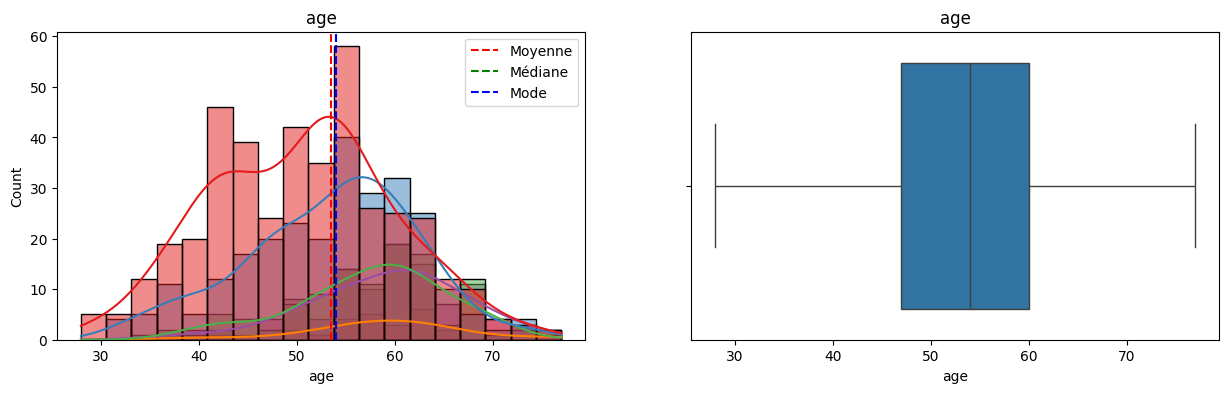

ca
Valeur minimale: 0.0, Valeur maximale: 3.0
Moyenne:  0.6763754045307443     Médiane:  0.0     Mode:  0.0


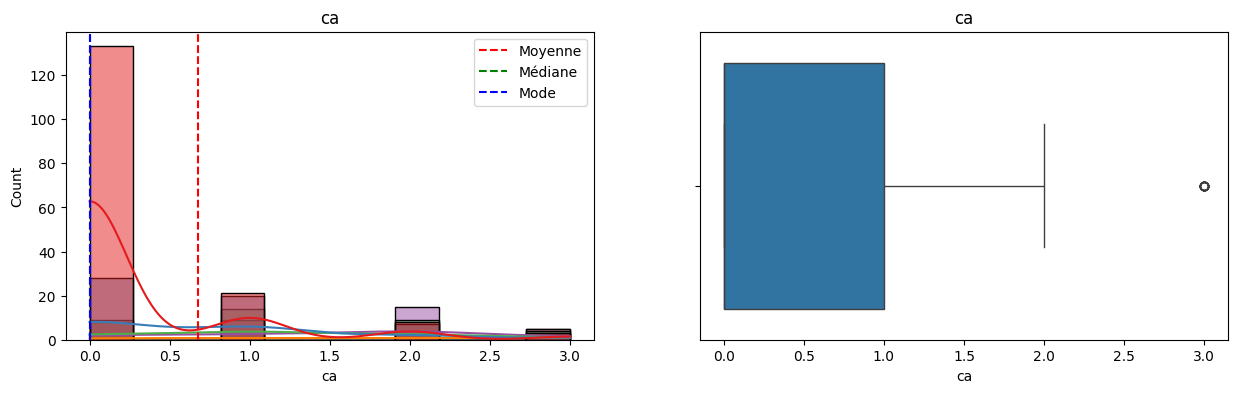

chol
Valeur minimale: 0.0, Valeur maximale: 603.0
Moyenne:  199.13033707865168     Médiane:  223.0     Mode:  0.0


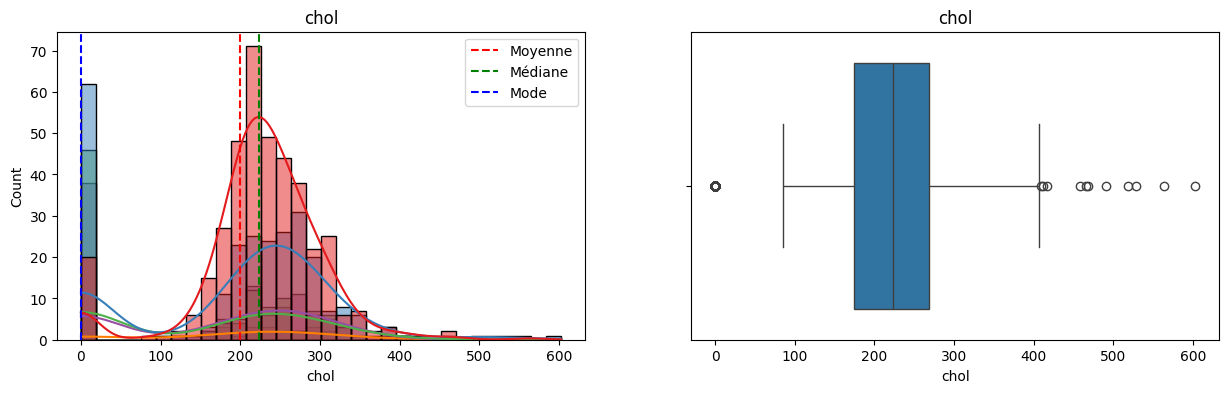

oldpeak
Valeur minimale: -2.6, Valeur maximale: 6.2
Moyenne:  0.8787878787878788     Médiane:  0.5     Mode:  0.0


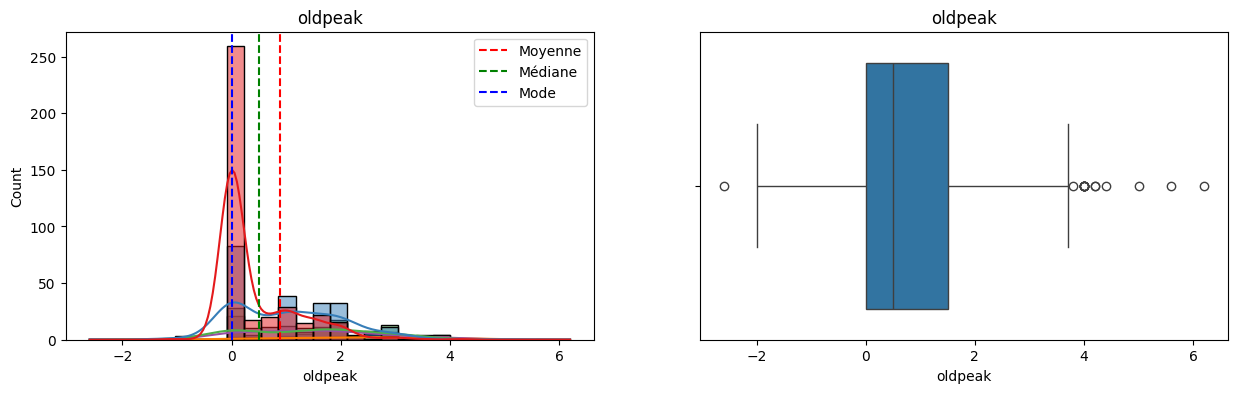

thalch
Valeur minimale: 60.0, Valeur maximale: 202.0
Moyenne:  137.5456647398844     Médiane:  140.0     Mode:  150.0


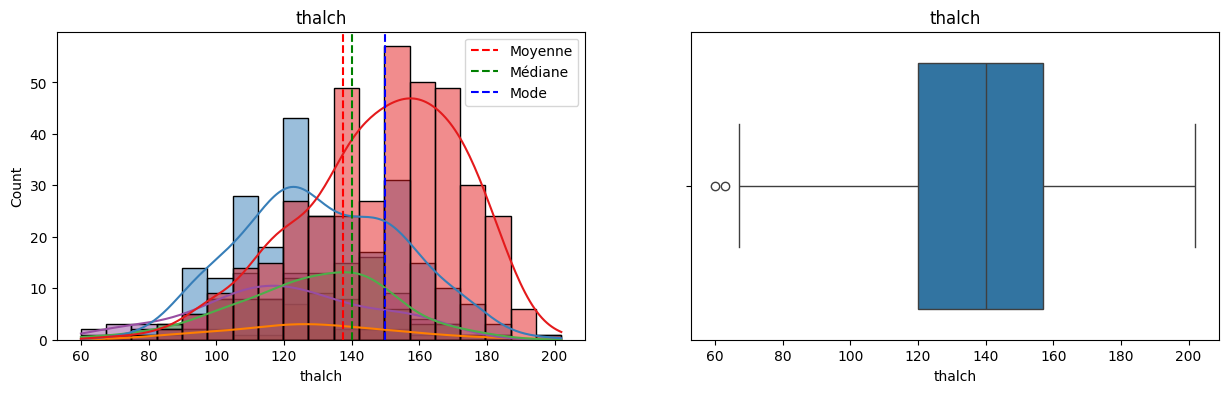

trestbps
Valeur minimale: 0.0, Valeur maximale: 200.0
Moyenne:  132.13240418118468     Médiane:  130.0     Mode:  120.0


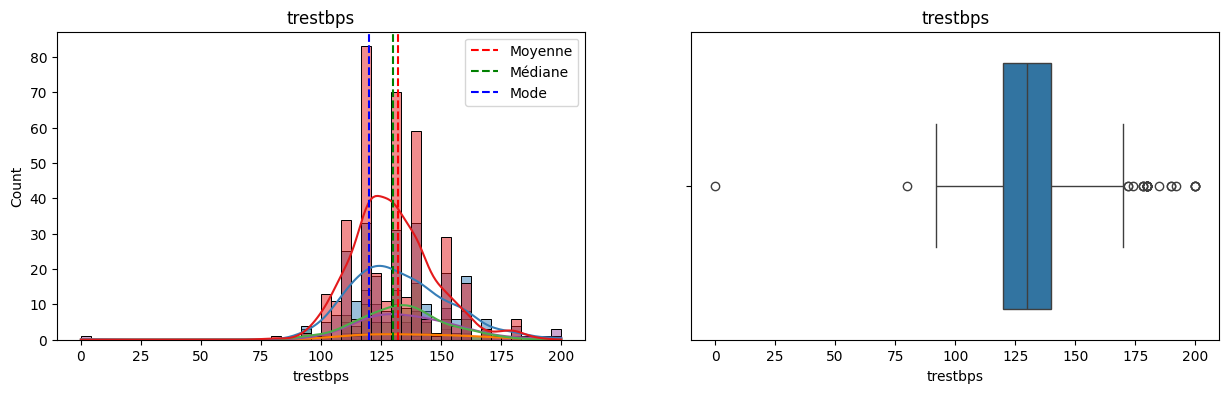

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sélection des variables numériques seulement
for col in ['age', 'ca', 'chol', 'oldpeak', 'thalch', 'trestbps']: # Boucle sur chaque colonne
    print(col) # Affiche variables numériques
    print(f"Valeur minimale: {df[col].min()}, Valeur maximale: {df[col].max()}") # Affiche la valeur min et max de chaque colonne contenant valeur numérique
    print("Moyenne: ", df[col].mean(),"    Médiane: ", df[col].median(),"    Mode: ", df[col].mode()[0]) # Affiche la moyenne, médiane et mode de chaque colonne contenant valeur numérique

    plt.figure(figsize=(15, 4)) # Taille

    # Création de l'histogramme avec KDE
    plt.subplot(1, 2, 1) # Nombre ligne dans grille, nombre colonnes grille, index sous-graphique dans grille
    sns.histplot(data=df, x=df[col], kde=True, hue='num', palette='Set1', legend=True) # Création du diagramme

    # Lignes verticales pour moyenne, médiane et mode pour chaque colonne
    plt.axvline(df[col].mean(), color='red', linestyle='--', label='Moyenne') # Ligne verticale rouge = moyenne
    plt.axvline(df[col].median(), color='green', linestyle='--', label='Médiane') # Ligne verticale verte = médiane
    plt.axvline(df[col].mode()[0], color='blue', linestyle='--', label='Mode') # Ligne verticale bleu = mode

    plt.ylabel('Count') # Axe des y (occurences)
    plt.title(col) # Nom de la colonne comme titre
    plt.legend() # Affiche légende

    # Création des boîte à moustaches
    plt.subplot(1, 2, 2) # Crée un sous-graphique dans la deuxième colonne et deuxième ligne de la grille
    plt.title(col) # Nom de la colonne comme titre
    sns.boxplot(x=df[col]) # Crée la boite pour chaque colonne : représente distribution données (quartiles, médianes, valeurs abhérentes)

    plt.show()

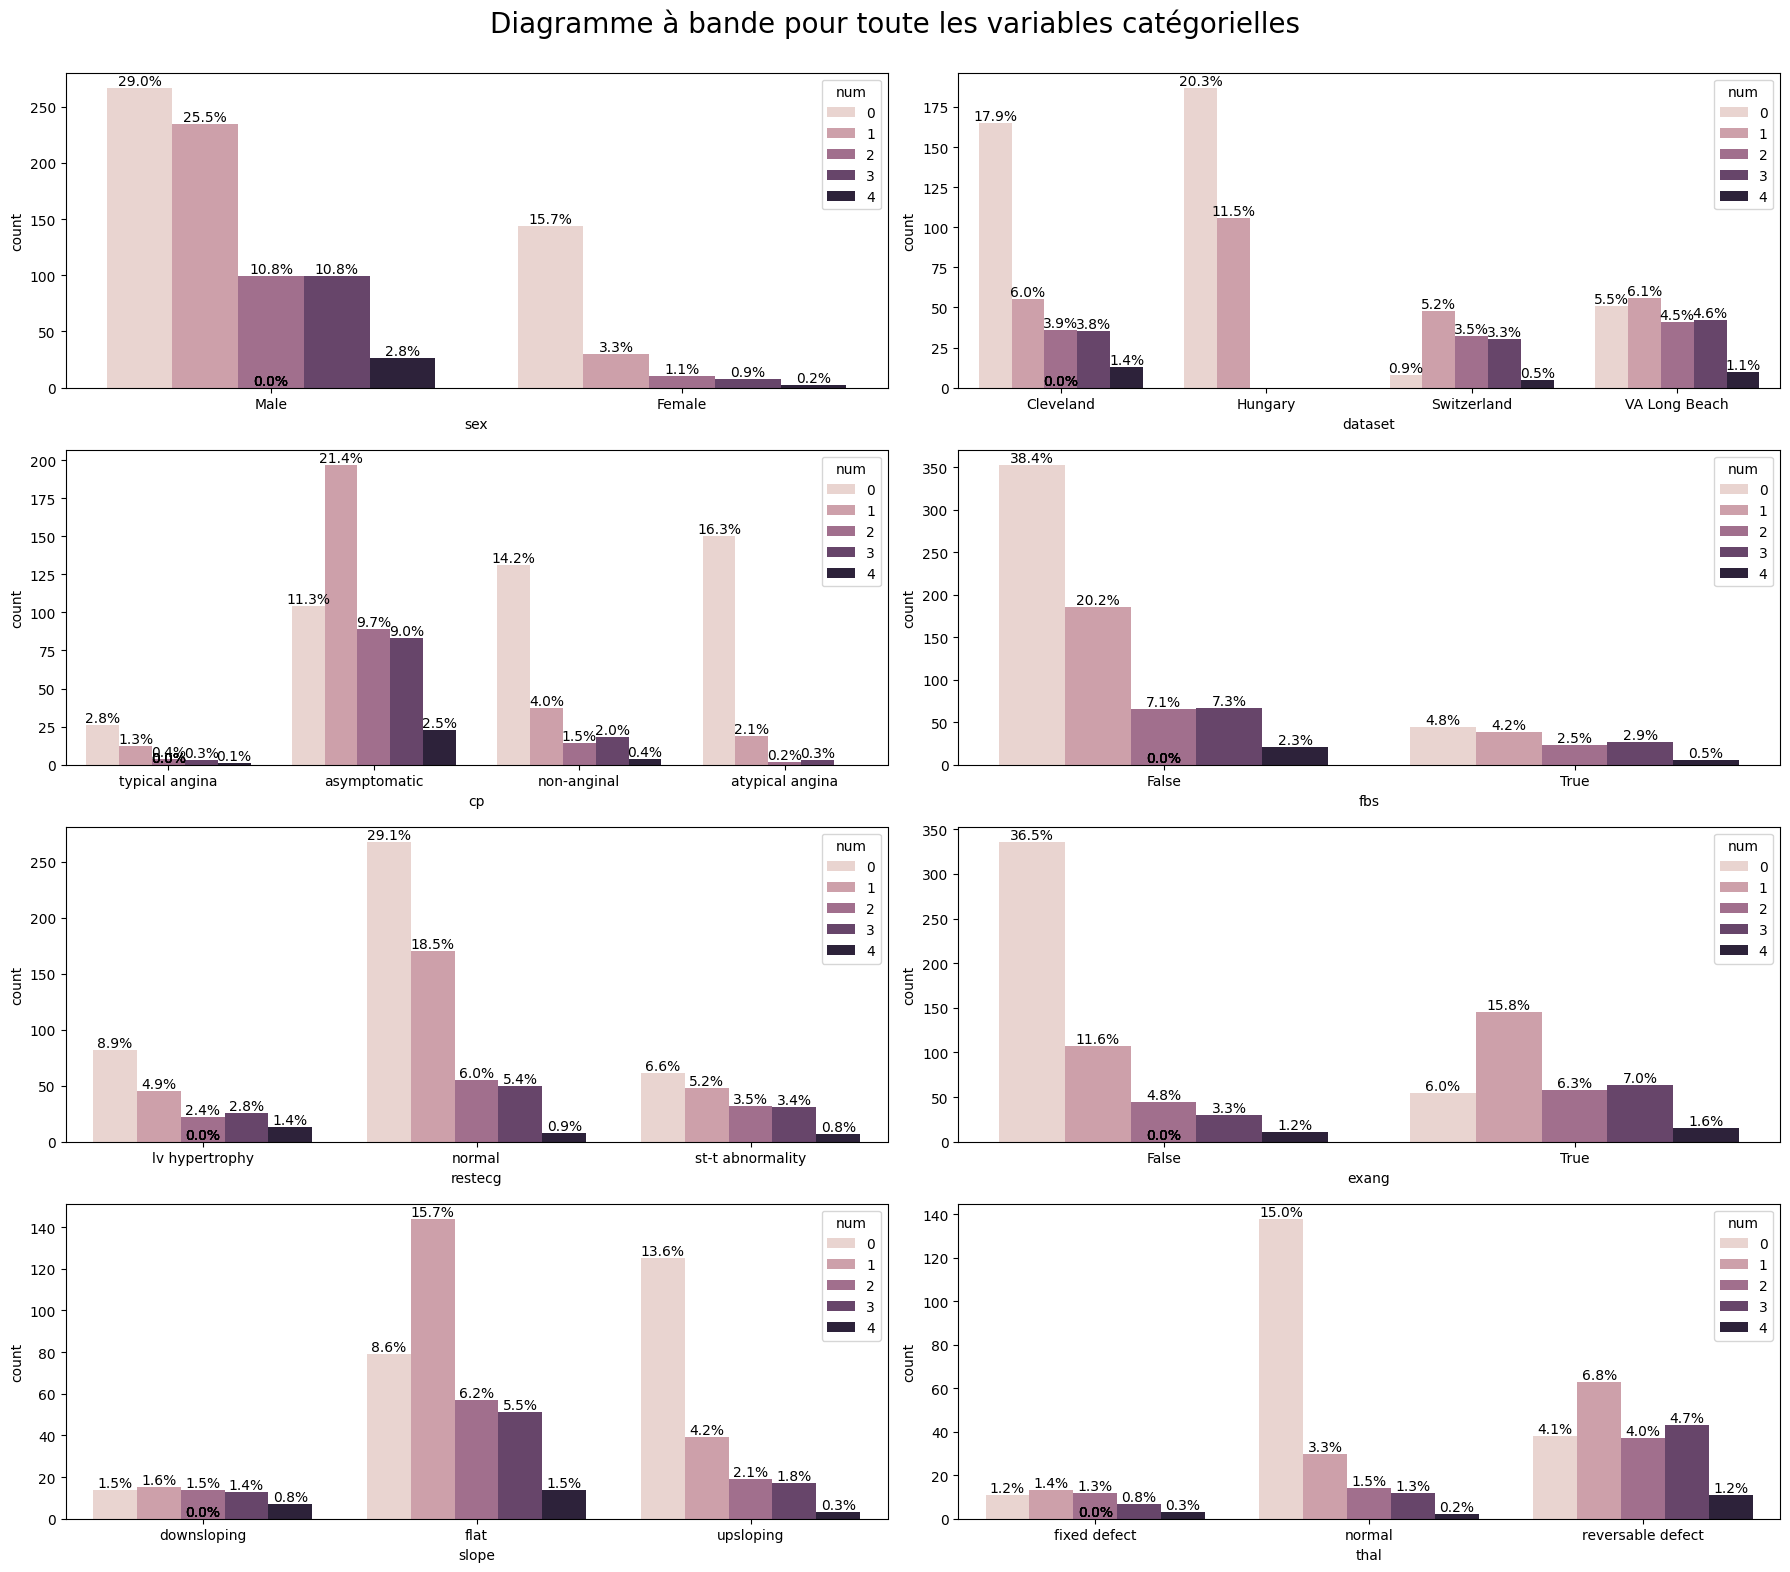

In [ ]:
# Diagramme a bandes pour les variables catégorielles

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(18, 16)) # Taille, axes de 4 lignes et 2 colonnes
plt.subplots_adjust(hspace=0.75) # Espacement entre les sous-graphiques, sinon trop collé

fig.suptitle('Diagramme à bande pour toute les variables catégorielles\n', fontsize=20) # Titre principale
plt.subplots_adjust(top=0.95) # Espacement entre titre principale et sous-graphique

# Sélection uniquement des colonnes avec des variables catégorielles
for i, column in enumerate(['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']):
    row = i // 2 # Position du sous-graphique dans la grille (ligne) avec l'index
    col = i % 2 # Position du sous-graphique dans la grile (colonne) avec l'index
    sns.countplot(ax=axes[row, col], x=column, data=df , hue='num') # Création du diagramme

    total_count = len(df[column]) # Calcule le nombre d'observation pour la variable courante

    for p in axes[row,col].patches: # Boucle qui parcourt chaque barre (patch) du diagramme
        percentage = f'{100 * p.get_height() / total_count:.1f}%' # Calcul du pourcentage .1f% (100 * hauteur barre/nbr observation)
        x_pos = p.get_x() + p.get_width() / 2 # Positionnement et annotation (récupère position + largeur / 2)
        y_pos = p.get_height() # Récupère hauteur barre = hauteur de la barre sur axe y
        axes[row,col].annotate(percentage, (x_pos, y_pos), ha='center', va='bottom') # Place le % au sommet de la barre

plt.tight_layout() # Ajustement automatique de l'affichage
plt.show()



---



**b.** Générer des cartes de chaleur (confusion matrix) pour visualiser la corrélation
entre les caractéristiques et expliquez vos résultats.

**Réponse :** Il n'y a pas de corrélation significative dans les résultats obtenues entre les variables numériques. Le maximum est de 1.0 (lorsque y augmente, x augmente aussi) et le minimum -1.0 (lorsque y augmente, x diminue). Plus on est proche de 0, plus les variables sont dîtes indépendantes l'une de l'autre. Généralement, on peut affirmer que 0.3 ou -0.3 constitue une faible corrélation, 0.5 ou -0.5 est modéré et une corrélation de 0.7 ou -0.7 commence a être très intéressante. Dans toute la heatmap, seulement la relation entre l'âge et thalch de -0.35. On pourrait donc affirmé qu'il y a une faible corrélation négative entre ces 2 variables.

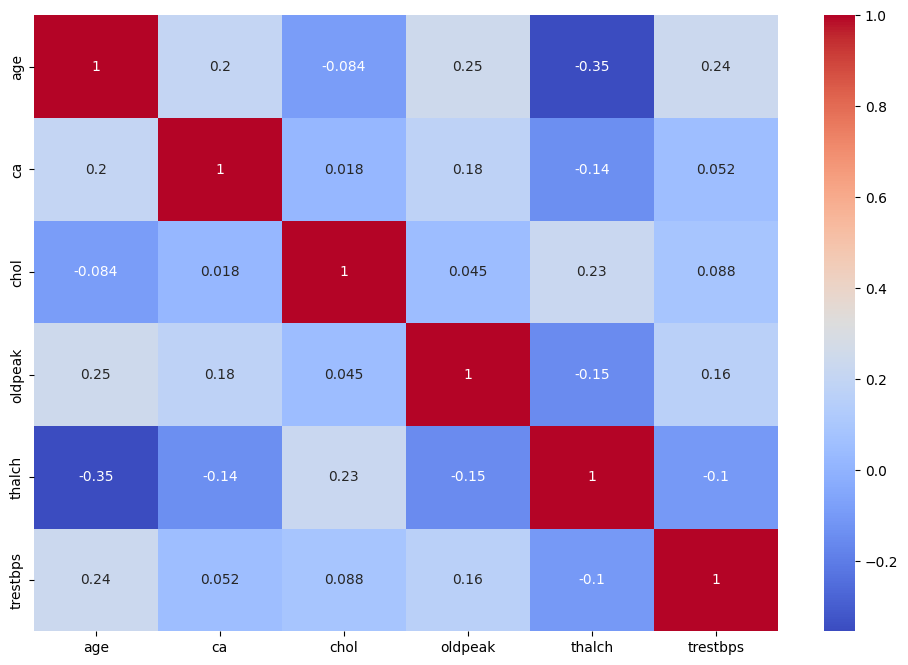

In [ ]:
# Sélection des colonnes numériques pour la corrélation
selected_columns = ['age', 'ca', 'chol', 'oldpeak', 'thalch', 'trestbps']
numeric_df = df[selected_columns] # Nouveau df avec seulement les valeurs numériques pour me simplifier la vie

# Génération de la carte de chaleur
plt.figure(figsize=(12, 8)) # Taille
sns.heatmap(numeric_df.corr(), cbar=True, cmap='coolwarm', annot=True) # Corrélation avec couleur coolwarm, légende (cbar) et valeur numériques pour chaque cellule
plt.show()



---



# Sélection des Caractéristiques

**a.** Utiliser des techniques statistiques et des connaissances du domaine pour
sélectionner les caractéristiques pertinentes pour la prédiction de la maladie.

***i.*** Pour cet exercice, vous devez trouver une méthode qui vous aide à choisir
les caractéristiques pertinentes pour la prédiction de la maladie.

**Réponse :** J'ai choisis d'utiliser la méthode RFE (Recursive Feature Elimination) avec la régression logistique comme modèle (estimateur). Tout d'abord, les 5 caractéristiques les plus pertinentes pour la prédiction de la maladie cardiaque sont séléctionner par le modèle. Ensuite, la précision, le rappel et le score F1 sont fournis pour chaque classe ('num'), ainsi que pour l'ensemble des données.

La colonne "precision" indique la proportion de prédictions vrai positives. Par exemple, pour la classe 0 (dans 'num' : pas de maladie cardiaque), 74% des prédictions positives étaient correctes.

La colonne "recall" indique la proportion de vrais positifs qui ont été correctement identifiés parmi tous les vrais positifs et faux négatifs. Par exemple, pour la classe 0, 89% des cas positifs ont été correctement identifiés.

Le score "F1" est une moyenne pondérée de la précision et du rappel, où 1 est le meilleur score et 0 est le pire. Il combine la précision et le rappel en un seul nombre. Par exemple, pour la classe 0, le score F1 est de 0.81.

La ligne "accuracy" indique la proportion d'échantillons correctement classés parmi tous les échantillons. Les colonnes "macro avg" et "weighted avg" fournissent la moyenne des scores pour toutes les classes, chacune calculée différemment. La macro moyenne (macro avg) donne le même poids à chaque classe, tandis que la moyenne pondérée (weighted avg) donne plus de poids aux classes avec plus d'échantillons.

Les résultats montrent que le modèle a une précision considérablement élevée pour prédire la classe 0 (absence de maladie cardiaque), et des performences moyenne pour la classe 1. Cependant, les performances sont de plus en plus faibles pour les autres classes. Il est possible que les mauvaises performance pour les classes 2, 3 et 4 indique des difficultés à distinguer ces classes en raison d'un manque de données ou de caractéristiques pertinentes.
Je lance l'hypothèse qu'il est possible que le modèle soit biaisé vers la prédiction de la classe majoritaire (classe 0) en raison d'un déséquilibre de classe dans les données d'entraînement.

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Sélection des caractéristiques et de la variable cible (on les sépares)
X = df_encoded.drop(columns=['num'])  # Séléctionne tout sauf la cible
y = df_encoded['num'] # Valeurs réels de la cible

# Initialisation du modèle d'apprentissage automatique (Régression logistique)
model = LogisticRegression(max_iter=1000, solver='liblinear')  # Augmenter max_iter à 1000 pour assurer convergence

# Initialisation de la méthode RFE (Recursive Feature Elimination) avec le modèle de régression logistique ci-haut
rfe = RFE(estimator=model, n_features_to_select=5)  # Choisir le nombre de caractéristiques à conserver (5 = les 5 plus importantes)

# Applique la méthode RFE aux données d'entrainement(X) et valeurs variable cible(y)
rfe.fit(X, y)

# Afficher les caractéristiques qui ont été sélectionnées
selected_features = X.columns[rfe.support_] # Noms des colonnes sélectionnées (True dans tableau rfe.support_)
print("Caractéristiques sélectionnées:", selected_features) # Affichage

# Entraînement du modèle de régression logistique sur l'ensemble des données pour apprendre les relations
model.fit(X, y)

# Faire des prédictions pour la variable cible selon les données d'entrainement.
y_pred = model.predict(X)

# Afficher le rapport de classification (compare valeur réel de la cible aux prédictions)
print(classification_report(y, y_pred))

Caractéristiques sélectionnées: Index(['sex', 'cp', 'exang', 'slope', 'ca'], dtype='object')
              precision    recall  f1-score   support

           0       0.73      0.89      0.80       411
           1       0.52      0.64      0.58       265
           2       0.28      0.08      0.13       109
           3       0.34      0.20      0.25       107
           4       0.50      0.04      0.07        28

    accuracy                           0.62       920
   macro avg       0.48      0.37      0.36       920
weighted avg       0.57      0.62      0.57       920





---



# Clustering pour le Profilage des Patients

**a.** Utilisez l'une des techniques de clustering hiérarchique discutées dans le cours
pour segmenter les patients en clusters basés sur leurs métriques de santé et
expliquez les résultats obtenus

**Réponse :** L'objectif du clustering est bien évidemment de regrouper les données similaires ensembles (dans un cluster spécifique). Dans ce cas-ci, chaque point représente un individus. Il y a quatre clusters distinct par la couleur. Les données en entrée = sur l'axe des x : age, sur l'axe des y : pression sanguine au repos, sur l'axe dez z : choléstérol. On peut évidemment modifier les métriques de santé selon ce que l'on souhaite visualiser. Le cluster 1 (rose) se démarque très facilement des autres. Il inclut les individus n'ayant pas de choléstérol et donc il est tapissé sur le sol du diagramme. Les 3 autres cluster semblent s'entremêler, mais je remarque tout de même une tendance du cluster 0 (bleu) à contenir les individus plus jeune et choléstérol un peu plus élevé. Le cluster 3 (jaune) semblent contenir les individus plus âgés avec un choléstérol légèrement plus bas. Le cluster 2 (orange) semble être une "moyenne" du cluster 0 et 3. C'est mon interprétation très débutante de la chose, je ne suis pas certain si c'était le type de réponse rechercher, mais c'est ce que j'ai compris de mon graphique!    

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px

# Sélection des caractéristiques voulues pour le clustering
X_cluster = df_encoded.drop(columns=['num'])  # Créer une matrice avec toute les colonnes du df sauf num

n_clusters = 4  # J'ai choisis 4 clusters ici. On peut le modifier et expérimenter

# Création de l'objet de clustering avec le modèle de clustering aglomératif
clustering_model = AgglomerativeClustering(n_clusters=n_clusters)

# Applique le modèle de clustering à la matrice contenant les données
clusters = clustering_model.fit_predict(X_cluster) # Chaque observation appartient à un cluster unique

# Figure 3D interactive. On change les variables sur axes x, y, z pour visualiser ce que l'on souhaite
fig = px.scatter_3d(X_cluster, x='age', y='trestbps', z='chol', color=clusters, labels={'color': 'Cluster'})
fig.update_layout(title='Visualisation des clusters en 3D') # Titre
fig.show()



---



**b.** Application d’un algorithme de clustering non discutée dans le cours (Exemple,
DBSCAN Clustering) avec vos données.

**Réponse :** J'ai expérimenter beaucoup avec l'epsilon (distance maximale entre deux échantillons pour les considérer comme dans le même voisinage) et le nombre minimum d'échantillon (min_samples dans un quartier pour définir un cluster) en évaluant les différents résultats et densité présente. Les résultats sont extrêmement variable, mais j'ai essayé de reproduire le diagramme obtenus avec le clustering aglomératif en a. Les entrées sont les mêmes. On remarque que le cluster 1 (orange) est répartis sur le plancher du diagramme. Celui-ci représente les individus n'ayant pas de choléstérol. Le cluster 2 (jaune) englobe les personnes plus âgés. Le cluster 0 (rose) semble se concentrer sur les personnes moins âgés. Le cluster -1 (bleu) semble majoritairement regrouper les données abhérentes pour le choléstérol (trop bas ou trop haut comparé à la moyenne).   

In [ ]:
from sklearn.cluster import DBSCAN

# Création d'une matrice en selectionnant toutes les colonnes du df sauf num
X_cluster = df_encoded.drop(columns=['num'])

# Création de l'objet de clustering DBSCAN avec un epsilon de 60 et échantillon minimum de 10 (les 2 modifiables pour expérimenter)
clustering_model = DBSCAN(eps=60, min_samples=10)

# Applique l'algorithme de clustering DBSCAN à la matrice contenant les données
clusters = clustering_model.fit_predict(X_cluster) # Chaque observation appartient à un cluster unique

# Figure 3D interactive. On change les variables sur axes x, y, z pour visualiser ce que l'on souhaite
fig = px.scatter_3d(X_cluster, x='age', y='trestbps', z='chol', color=clusters, labels={'color': 'Cluster'})
fig.update_layout(title='Visualisation des clusters en 3D') # Titre
fig.show()



---



**c.** Comparez les résultats obtenus dans les étapes a et b.

**Réponse :** En a, avec l'utilisation du clustering aglomératif, j'ai identifié quatre clusters distincts basés sur les métriques de santé des patients. Le cluster 1 (rose) se démarque clairement des autres, regroupant les individus sans cholestérol. La même observation a été faite en b à l'aide du DBSCAN avec le cluster 1 (orange). Il y a également 4 clusters, mais avec des observations légèrement différentes.

En comparant les deux approches, j'ai constaté plusieurs similitudes dans la capacité des deux méthodes à identifier des groupes distincts basés sur les métriques de santé. Ceux-ci vont variés selon l'algorithme utilisé et ses paramètres. Le clustering hiérarchique a produit des clusters moins compacts et plus étendu, ce qui nous indiques une certaine variabilité dans les métriques de santé à l'intérieur de chaque cluster. En revanche, les clusters DBSCAN étaient plus compacts et plus dense, ce qui nous suggères une meilleure séparation des données selon leurs caractéristiques de santé.

Je sais que DBSCAN est plus robuste aux données aberrantes et aux bruitages dans les données, tandis que le clustering hiérarchique est plus sensible à cela. Cela peut expliquer en partis pourquoi les données sont moins condensé dans le clustering hiérarchique.  




---



# Évaluation de la qualité du Clustering

**a.** Déterminez le nombre optimal de clusters pour le clustering hiérarchique et le
DBSCAN en utilisant les résultats obtenus dans la question 8, avec les méthodes
du 'Elbow', le 'Silhouette Score' et la 'Normalized Mutual Information (NMI)'.

**Réponse :** Malheureusement, j'ai rencontré plusieurs problèmes en tentant d'implémenter le NMI. L'heure de remise de ce présent projet se rapproche de plus en plus, donc dans un soucis d'avoir le temps de créer et expliquer le tableau comparatif des deux autres méthodes, j'ai décider d'aller de l'avant, car je n'ai plus le temps pour essayer des solutions. Ceci étant dit, j'ai utilisé la méthode du coude sur les 2 algo de clustering, puis la méthode du score silhouette. J'ai insérer les résultats dans un tableau et expliquez de façon détaillé tout les résultats à la fin de tout ce code.  

Aglomératif elbow

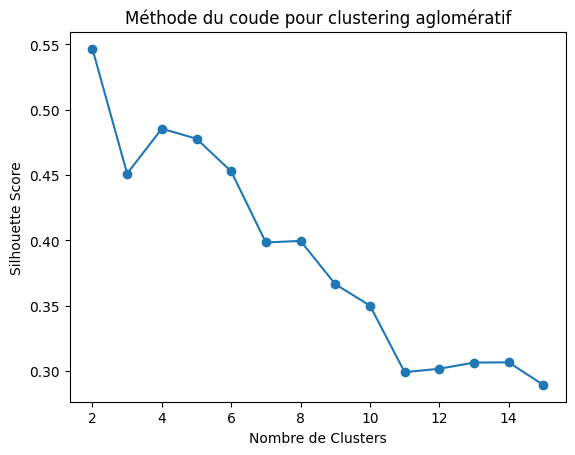

In [ ]:
from sklearn.metrics import silhouette_score, normalized_mutual_info_score

# Liste vide pour stocker les valeurs du coude
sse_1 = []

# Nombre maximal raisonable de clusters à tester
max_clusters = 15

# Calculer la somme des erreurs au carré (SSE) pour chaque nombre de clusters
for n_clusters in range(2, max_clusters+1): # Itère sur tout les clusters (à partir de 2) jusqu'à max+1 pour alignement index
    clustering_model = AgglomerativeClustering(n_clusters=n_clusters) # Création modèle cluster aglomératif
    clusters = clustering_model.fit_predict(X_cluster) # Applique algorithme cluster aglomératif sur la matrice de données
    silhouette_avg = silhouette_score(X_cluster, clusters) # Calcule le score de silhouette moyen pour l'affectation de clusters
    sse_1.append(silhouette_avg) # Ajoute le score silhouette moyen à la liste sse_1

# Tracer la courbe du coude pour avoir un apercue visuel
plt.plot(range(2, max_clusters+1), sse_1, marker='o', linestyle='-') # Crée le graphique en fonction du nombre de cluster et score
plt.xlabel('Nombre de Clusters') # Titre axe x
plt.ylabel('Silhouette Score') # Titre axe y
plt.title('Méthode du coude pour clustering aglomératif') # Titre graphique
plt.show()



---



DBSCAN elbow

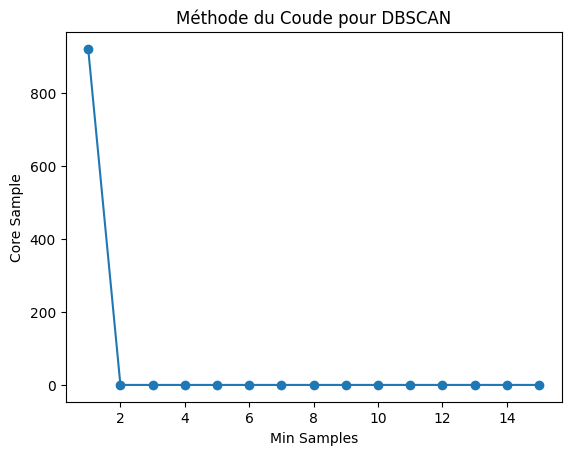

In [ ]:
# Liste vide pour stocker les valeurs du coude
sse_2 = []

# Nombre maximal raisonable de clusters à tester
max_clusters = 15

# Calculer la somme des erreurs au carré (SSE) pour chaque nombre de clusters
for min_samples in range(1, max_clusters+1): # Itère de min_sample(1) jusqu'à max cluster+1 pour alignement index
    clustering_model = DBSCAN(min_samples=min_samples) # Création du modèle DBSCAN clustering
    clusters = clustering_model.fit_predict(X_cluster) # Applique l'algorithme aux données de la matrice et stocke les étiquettes de cluster
    sse_2.append(clustering_model.core_sample_indices_.size) #  Ajoute les core samples (points denses qui forment la base des clusters) à la liste sse_2

# Tracer la courbe du coude pour avoir un apercu visuel
plt.plot(range(1, max_clusters+1), sse_2, marker='o', linestyle='-') # Crée le graphique pour visualer valeurs des core samples en fonction des min_samples
plt.xlabel('Min Samples') # Titre axe x
plt.ylabel('Core Sample') # Titre axe y
plt.title('Méthode du Coude pour DBSCAN') # Titre graphique
plt.show()



---



Aglomératif silhouette score

In [ ]:
# Liste pour stocker les scores de silhouette moyen pour chaque cluster testé
silhouette_scores = []

# On calcule le score silhouette
for n_clusters in range(2, 11): # Itère sur 2 à 10 inclus cluster
    clustering_model = AgglomerativeClustering(n_clusters=n_clusters) # Crée un modèle cluster aglomératif
    clusters = clustering_model.fit_predict(X_cluster) # Applique l'algorithme du cluster aglomératif sur les données dans la matrice et stocke les étiquettes de cluster résultante
    silhouette_scores.append(silhouette_score(X_cluster, clusters)) # Calcule le score de de silhouette moyen pour affectation cluster. Ajoute le score à la liste.

# Ici pour trouver le nombre de clusters optimale qui maximise le score de silhouette
optimal_clusters_silhouette = silhouette_scores.index(max(silhouette_scores)) + 2 # Trouve l'index du score silhouette max d'un groupe de cluster + 2 car boucle commence a 2
print("Nombre optimal de clusters selon le Silhouette Score :", optimal_clusters_silhouette)

Nombre optimal de clusters selon le Silhouette Score : 2




---



DBSCAN silhouette score

In [ ]:
from sklearn.cluster import DBSCAN

# Liste pour stocker les scores de silhouette moyen pour chaque valeur d'epsilon testé
silhouette_scores_dbscan = []

# Liste de différent paramètre eps à testé
eps_values = [0.1, 0.5, 1, 2, 5, 10, 15, 20, 30, 40, 50, 60, 80, 100, 120, 140, 160]

# On calcule le score silhouette
for eps in eps_values: # Itère sur chaque valeur eps dans la liste
    clustering_model = DBSCAN(eps=eps, min_samples=5) # Crée un modèle DBSCAN avec paramètre eps et min_sample
    clusters = clustering_model.fit_predict(X_cluster) # Applique algorithme DBSCAN aux données dans la matrice et stocke les étiquettes résultantes
    if len(set(clusters)) > 1: # Vérifie que DBSCAN a identifier au minimum 2 clusters
        silhouette_scores_dbscan.append(silhouette_score(X_cluster, clusters)) # Score de silhouette calculé et appliqué à la liste
    else: # Moins de 2 clusters (eps trop grand)
        silhouette_scores_dbscan.append(-1) # Score arbitraire de -1 ajouté à la liste (cette valeur eps n'est pas pertinente)

# Trouver le meilleur paramètre optimale epsilon qui maximise le score de silhouette
optimal_eps = eps_values[silhouette_scores_dbscan.index(max(silhouette_scores_dbscan))] # Récupere l'index de la valeur eps correspondante à l'index du score silhouette max
print("Meilleur paramètre epsilon selon le Silhouette Score :", optimal_eps)

Meilleur paramètre epsilon selon le Silhouette Score : 100




---



***i.*** Expliquez les résultats

***ii.*** Veuillez noter que votre résultat doit être un tableau montrant les résultats
de la comparaison. Vous devez également expliquer vos résultats.

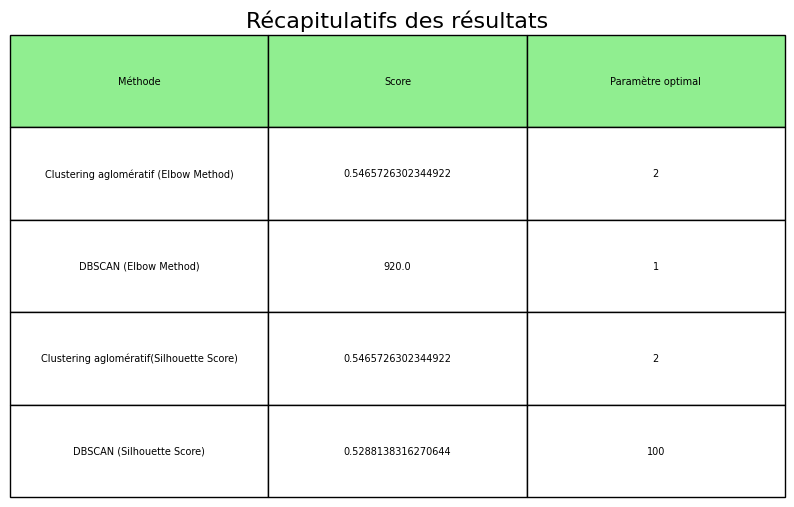

In [ ]:
# Section de code pour créer un tableau récapitulatif des résultats obtenus

results_summary = pd.DataFrame({ # Nouveau df créer pour tableau de données
    "Méthode": ["Clustering aglomératif (Elbow Method)", "DBSCAN (Elbow Method)",
               "Clustering aglomératif(Silhouette Score)", "DBSCAN (Silhouette Score)"], # Noms des méthodes de clustering et critères évaluation utilisé (coude, silhouette)
    "Score": [max(sse_1), max(sse_2), max(silhouette_scores), max(silhouette_scores_dbscan)], # Valeur max obtenues pour chaque méthode et critère
    "Paramètre optimal": [sse_1.index(max(sse_1)) + 2, sse_2.index(max(sse_2)) + 1,
                          optimal_clusters_silhouette, optimal_eps] # Nombre de cluster optimale de clusters identifiés par chaque méthode et critère
})

# Affichage du tableau récapitulatif avec couleurs et formatage
fig, ax = plt.subplots(figsize=(10, 6)) # Taille
ax.axis('off') # Masque axe x et axe y
ax.table(cellText=results_summary.values, # Définis contenue des cellules du tableau avec valeur du df
         colLabels=results_summary.columns, # Définis étiquettes des colonnes du tableau avec noms dans df
         cellLoc='center', # Centre horizontalement le contenue des cellules et le tableau
         loc='center', # Centre verticalement le contenue des cellules et le tableau
         colColours=['lightgreen'] * len(results_summary.columns), # Couleur pour les colonnes
         bbox=[0, 0, 1, 1], # Définis la zone d'affichage du tableau (totalité de la figure)
         rowLoc='center') # Centre verticalement le contenu des lignes du tableau
plt.title("Récapitulatifs des résultats", fontsize=16) # Titre
plt.show()

**Réponse :**

**Le clustering aglomératif qui utilise la méthode du coude** nous donnes un score arrondis de 0.55. Il représente la distance moyenne des points dans un cluster par rapport au point central du cluster. Plus le score est élevé, moins les points sont groupés, donc plus les clusters sont distincts. Plus le score est faible, plus les points sont proche du centre. Dans notre cas, cela indique une cohésion des points relativemment correcte dans les clusters. Ensuite, on remarque que le nombre de cluster optimal est de 2. La façon que cela est calculer est simple. Pour chaque nombre de clusters, le SSE (mesure de variation à l'intérieur des clusters) est calculé. Plus celui-ci est faible, meilleure va être la cohésion à l'intérieur des clusters.
On peut ensuite faire un graphique avec les valeurs du SSE par rapport au nombre de cluster. On va donc avoir un graphique où l'axe des x représente le nombre de clusters et l'axe des y représente le SSE. Il suffit juste de regarder le graphique puis chercher le point où le SSE commence à diminuer de façon linéaire ou à "couder". Ce coude représente le nombre optimal de clusters où même si on ajoute des clusters, ça ne va pas affecter significativement le SSE. Bref, le nombre de cluster correspondant au coude du modèle aglomératif avec mes données est de 2.

**Le DBSCAN avec la méthode en coude** n'est pas très pertinente en général. En fait DBSCAN ne nécessite pas la spécification du nombre de cluster en avance comme la méthode aglomérative. Celui-ci détermine le nombre de clusters en fonction de la densité des points. DBSCAN n'essaie pas de minimiser le SSE. De plus, l'epsilon et le minimum d'échantillon vont jouer un rôle significatif sur l'identification des clusters. Nous obtenons donc 1 comme nombre de cluster optimal, mais ça ne veut pas dire grand chose au final. Le score de 920 représente le nombre de core sample. C'est-à-dire, un point qui a suffisament de points voisins selon le paramètre epsilon définis. Le score varie dépendemment de l'epsilon et de l'échantillon minimum. Le score de 920 dans ce contexte-ci signifie seulement que 920 points qui répondent aux paramètres ont été identifié ; il n'y a pas 920 clusters, mais ces points sont plutôt groupés en clusters.    

**Le clustering aglomératif avec la méthode silhouette** donne un résultat de 0.5465. Celui-ci mesure la cohésion intra-cluster et la séparation inter-cluster. Si son score est élevé, cela veut dire que les clusters sont bien groupéset bien séparé des autres clusters. Le nombre optimal de clusters détérminé est aussi de 2, ce qui est cohérent avec le résultat obtenu avec la méthode du coude.

**Le DBSCAN avec la méthode silhouette** nous donnes un résultat de 0.53 arrondis. L'epsilon que j'avais définis à la base (60) est similaire à celui recommander (100). Donc, selon l'algorithme, un epsilon de 100 serait optimale pour identifier les points appartenant au même cluster ou non.  



---



**b.** Visualisez les clusters et interpréter les caractéristiques qui définissent chaque
cluster (par ex., patients à haut risque pour la maladie, patients avec des paramètres
de santé contrôlés, etc.).

**Réponse :** Je vais ré-utiliser exactement le même code que dans la section précèdente ou j'utilisais des clustering en 3D pour visualiser les données. Cette fois-ci, je vais modifier les paramètres selon ce qui est optimale. Donc, avec le clustering aglomératif, je vais définir le nombre de cluster a 2. Pour le clustering DBSCAN, je vais définir l'epsilon à 100. Une interprétation des nouveaux clusters est incluse à la fin.  

In [ ]:
# Clustering aglomératif

# Sélection des caractéristiques voulues pour le clustering aglomératif
X_cluster = df_encoded.drop(columns=['num'])  # Créer une matrice avec toute les colonnes du df sauf num

n_clusters = 2  # Nombre de clusters optimale

# Création de l'objet de clustering avec le modèle de clustering aglomératif
clustering_model = AgglomerativeClustering(n_clusters=n_clusters)

# Applique le modèle de clustering à la matrice contenant les données
clusters = clustering_model.fit_predict(X_cluster) # Chaque observation appartient à un cluster unique

# Figure 3D interactive. On change les variables sur axes x, y, z pour visualiser ce que l'on souhaite
fig = px.scatter_3d(X_cluster, x='age', y='trestbps', z='chol', color=clusters, labels={'color': 'Cluster'})
fig.update_layout(title='Visualisation des clusters en 3D') # Titre
fig.show()

In [ ]:
# Clustering DBSCAN

# Création d'une matrice en selectionnant toutes les colonnes du df sauf num
X_cluster = df_encoded.drop(columns=['num'])

# Création de l'objet de clustering DBSCAN avec un epsilon optimale de 100 et échantillon minimum de 10 (les 2 modifiables pour expérimenter)
clustering_model = DBSCAN(eps=100, min_samples=10)

# Applique l'algorithme de clustering DBSCAN à la matrice contenant les données
clusters = clustering_model.fit_predict(X_cluster) # Chaque observation appartient à un cluster unique

# Figure 3D interactive. On change les variables sur axes x, y, z pour visualiser ce que l'on souhaite
fig = px.scatter_3d(X_cluster, x='age', y='trestbps', z='chol', color=clusters, labels={'color': 'Cluster'})
fig.update_layout(title='Visualisation des clusters en 3D') # Titre
fig.show()

Je remarque déjà que le tout est bien plus clair, selon moi. Je vais interpréter chacun des algorithmes de clustering selon les même variables sur les axes x, y, z qui sont utilisés depuis le début. J'aurais aimer pousser l'analyse un peu plus loin et entrer d'autre variables sur les axes pour avoir un portait globale plus complet et enrichir davantage mon interprétation, mais malheureusement je manque de temps. Je vais donc m'en tenir aux 3 mêmes variables.

**Cluster aglomératif :** La différence entre les clusters est beaucoup plus évidente avec seulement 2 clusters. Le cluster 0 (bleu) inclus seulement les individus avec du cholestérol avec une tendance élevé. Les âges et pression sanguine sont variés. On remarque donc que le cluster 0 distingue les individus souffrant de cholestérol avec une tendance élevé, tout âge et pression sanguine confondus. Maintenant, le cluster 1 (jaune) inclus tout les individus ne souffrant pas de cholestérol. Le cluster 1 inclus également des individus avec cholestérol, mais dans l'ensemble celui-ci est plus bas que le cluster 0. Aussi, je distingue que les individus plus âgé se trouve majoritairement dans le cluster 0. J'en déduis donc que le cluster 0 représente un groupe de patient plus âgé, ne souffrant pas (ou pas trop élevé) de cholestérol, avec une pression sanguine régulière.

**Cluster DBSCAN :** Les résultats obtenus sont très similaire aux précèdents avec une valeur epsilon de 60. Toutefois, on remarque que les clusters sont plus distingués les uns des autres. On remarque que le cluster 1 (orange) est encore répartis sur le plancher du diagramme. On peut affirmer avec confiance que ce cluser représente un groupe d'individus, tout âge et pression sanguine confondus, qui n'ont absolument pas de choléstérol. Le cluster 2 (jaune) englobe toujours un groupe de patient qu'on pourrait qualifier de personnes plus âgés, tout niveau de cholestérol et pression sanguine confondus. Le cluster 0 (rose) semble encore se concentrer sur les personnes moins âgés. On pourrait donc le définir d'un groupe de patient plus jeune, tout niveau de cholestérol et pression sanguine confondus. Le cluster -1 (bleu) regroupe encore les données abhérentes pour le choléstérol (trop bas ou trop haut comparé à la moyenne). Ce cluster n'est pas très pertinent, car il ne nous apprends rien sur un groupe de patient en particulier.



---

